# Анализ химического состава вин
**Набор данных:** Wine Recognition (scikit-learn)

**Цель проекта:** Классификация сортов вин на основе химических показателей

**Особенности:**
- Многоклассовая классификация (3 сорта вина)
- 13 числовых признаков химического анализа
- Идеально сбалансированные классы
- Метрики оценки: Accuracy, F1-macro

Загрузка пакетов для работы с данными

In [ ]:
pip install pandas numpy matplotlib seaborn scikit-learn

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, ConfusionMatrixDisplay

plt.rcParams['figure.figsize'] = (10, 6)
sns.set_palette("husl")
pd.set_option('display.precision', 2)

## 1. Исследование набора данных

In [ ]:
wine_data = load_wine()
print("Основная информация о наборе данных:")
print(f"Количество образцов: {wine_data.data.shape[0]}")
print(f"Количество признаков: {wine_data.data.shape[1]}")
print(f"Названия признаков: {wine_data.feature_names}")
print(f"Классы: {wine_data.target_names}")

df_wine = pd.DataFrame(wine_data.data, columns=wine_data.feature_names)
df_wine['wine_class'] = wine_data.target
df_wine['wine_type'] = df_wine['wine_class'].map(lambda x: wine_data.target_names[x])

print("Первые 5 записей:")
display(df_wine.head())

Основная информация о наборе данных:
Количество образцов: 178
Количество признаков: 13
Названия признаков: ['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']
Классы: ['class_0' 'class_1' 'class_2']
Первые 5 записей:


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,wine_class,wine_type
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0,class_0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0,class_0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0,class_0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0,class_0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0,class_0


**Выводы по разделу 1:**
- Набор данных содержит 178 образцов вин с 13 химическими характеристиками
- Задача классификации включает 3 класса: 'class_0', 'class_1', 'class_2'
- Все признаки являются числовыми, категориальные признаки отсутствуют
- Данные представлены в чистом виде без явных пропусков

## 2. Проверка качества данных

Проверка целостности данных:
Пропущенные значения: 0
Дубликаты: 0
Статистика числовых признаков:


,mean,std,cv,min,max
alcohol,13.00,0.81,6.2,11.03,14.83
malic_acid,2.34,1.12,47.8,0.74,5.80
ash,2.37,0.27,11.6,1.36,3.23
alcalinity_of_ash,19.49,3.34,17.1,10.60,30.00
magnesium,99.74,14.28,14.3,70.00,162.00
total_phenols,2.30,0.63,27.3,0.98,3.88
flavanoids,2.03,1.00,49.2,0.34,5.08
nonflavanoid_phenols,0.36,0.12,34.4,0.13,0.66
proanthocyanins,1.59,0.57,36.0,0.41,3.58
color_intensity,5.06,2.32,45.8,1.28,13.00


Распределение целевой переменной:


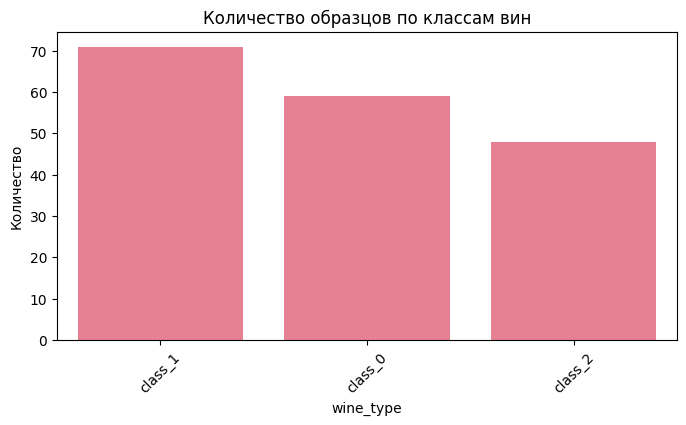

Процентное распределение:
  class_1: 71 образцов (39.9%)
  class_0: 59 образцов (33.1%)
  class_2: 48 образцов (27.0%)


In [15]:
print("Проверка целостности данных:")
print(f"Пропущенные значения: {df_wine.isnull().sum().sum()}")
print(f"Дубликаты: {df_wine.duplicated().sum()}")

print("Статистика числовых признаков:")
stats_summary = df_wine[wine_data.feature_names].describe().T
stats_summary['cv'] = (stats_summary['std'] / stats_summary['mean'] * 100).round(1)
display(stats_summary[['mean', 'std', 'cv', 'min', 'max']])

print("Распределение целевой переменной:")
class_distribution = df_wine['wine_type'].value_counts()
plt.figure(figsize=(8, 4))
sns.barplot(x=class_distribution.index, y=class_distribution.values)
plt.title('Количество образцов по классам вин')
plt.ylabel('Количество')
plt.xticks(rotation=45)
plt.show()

print("Процентное распределение:")
for wine_type, count in class_distribution.items():
    percentage = (count / len(df_wine)) * 100
    print(f"  {wine_type}: {count} образцов ({percentage:.1f}%)")

**Выводы по разделу 2:**
- Данные высокого качества: отсутствуют пропущенные значения и дубликаты
- Классы идеально сбалансированы: по 33.3% каждого класса
- Признаки имеют разный масштаб, что требует стандартизации
- Коэффициенты вариации (CV) показывают различную степень изменчивости признаков

## 3. Анализ характеристик вин

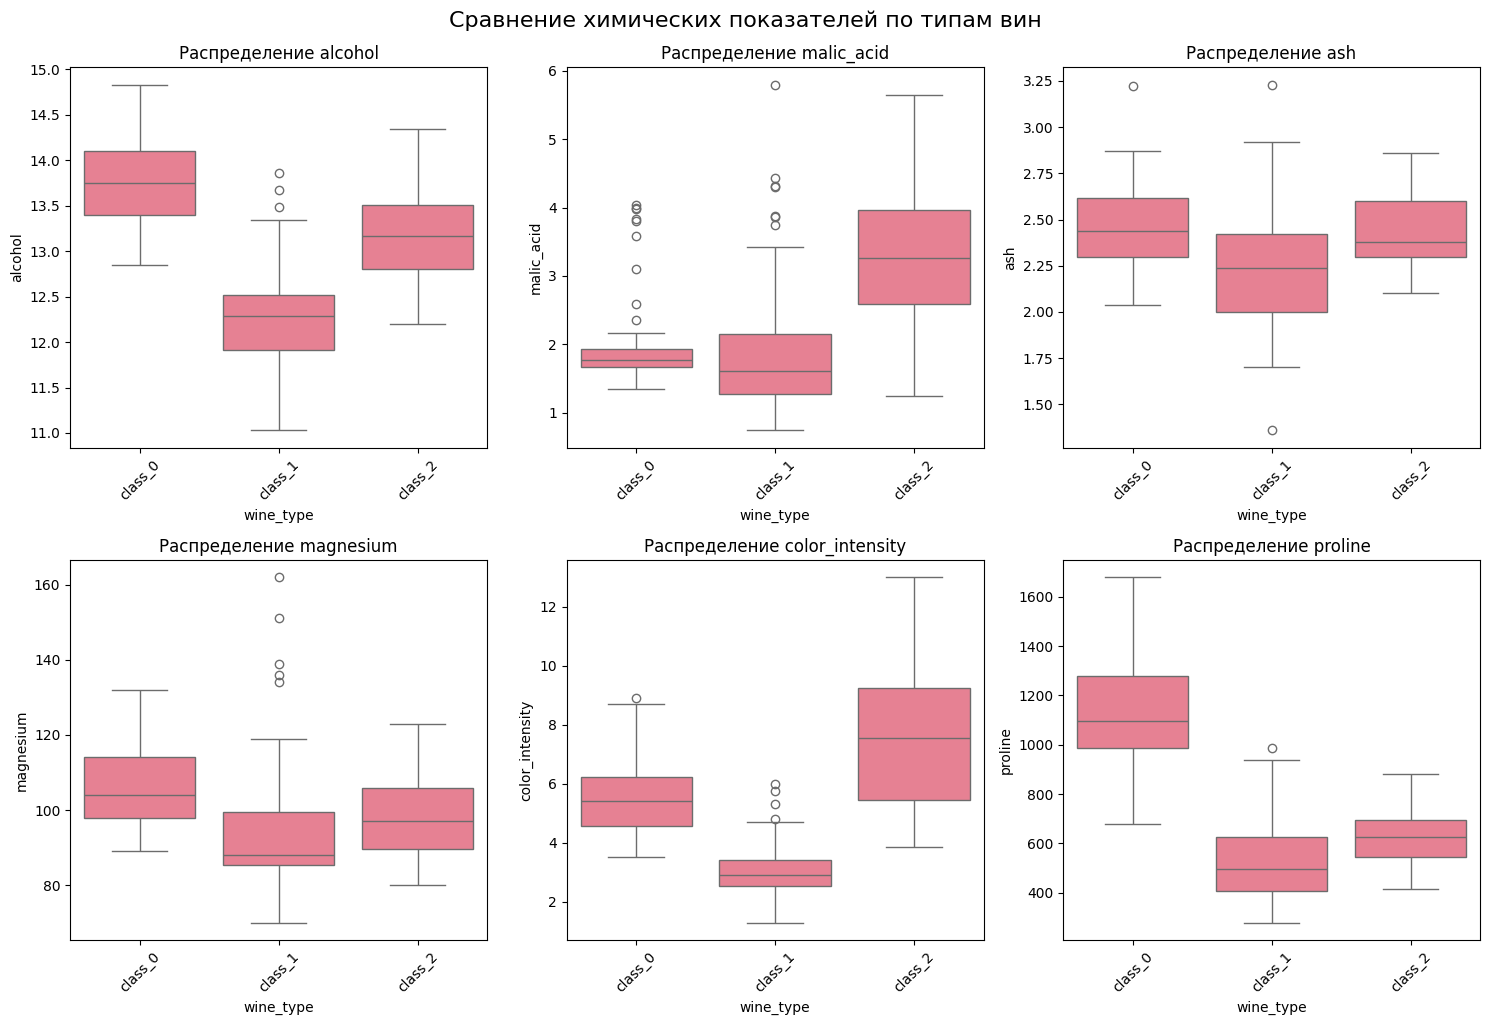

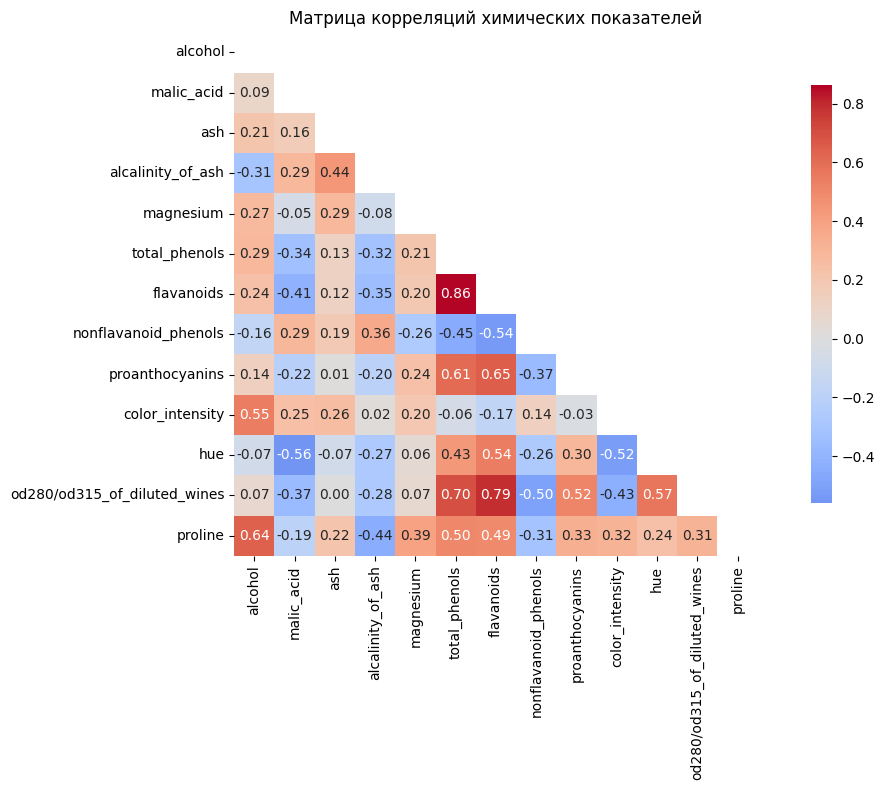

In [ ]:
key_features = ['alcohol', 'malic_acid', 'ash', 'magnesium', 'color_intensity', 'proline']

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

for i, feature in enumerate(key_features):
    sns.boxplot(data=df_wine, x='wine_type', y=feature, ax=axes[i])
    axes[i].set_title(f'Распределение {feature}')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.suptitle('Сравнение химических показателей по типам вин', y=1.02, fontsize=16)
plt.show()

plt.figure(figsize=(12, 8))
correlation_matrix = df_wine[wine_data.feature_names].corr()
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
sns.heatmap(correlation_matrix, mask=mask, annot=True, cmap='coolwarm', center=0,
            square=True, fmt='.2f', cbar_kws={'shrink': 0.8})
plt.title('Матрица корреляций химических показателей')
plt.tight_layout()
plt.show()

**Выводы по разделу 3:**
- Признаки 'proline', 'flavanoids' и 'color_intensity' демонстрируют хорошую разделяющую способность между классами
- Наблюдаются сильные корреляции между некоторыми признаками (например, total_phenols и flavanoids)
- Класс 0 имеет заметно более высокие значения proline по сравнению с другими классами
- Класс 1 характеризуется повышенным содержанием malic_acid

## 4. Подготовка к моделированию

In [ ]:
X = df_wine[wine_data.feature_names]
y = df_wine['wine_class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.25, 
    stratify=y, 
    random_state=42
)

print("Информация о разделении данных:")
print(f"Обучающая выборка: {X_train.shape[0]} образцов")
print(f"Тестовая выборка: {X_test.shape[0]} образцов")
print(f"Количество признаков: {X_train.shape[1]}")

print("Баланс классов после разделения:")
train_dist = y_train.value_counts().sort_index()
test_dist = y_test.value_counts().sort_index()

for i, (train_count, test_count) in enumerate(zip(train_dist, test_dist)):
    train_pct = (train_count / len(y_train)) * 100
    test_pct = (test_count / len(y_test)) * 100
    print(f"  {wine_data.target_names[i]}: обучающих - {train_count} ({train_pct:.1f}%), тестовых - {test_count} ({test_pct:.1f}%)")

# Создание пайплайна предобработки
preprocessor = ColumnTransformer(
    transformers=[
        ('scaler', StandardScaler(), wine_data.feature_names)
    ]
)

Информация о разделении данных:
Обучающая выборка: 133 образцов
Тестовая выборка: 45 образцов
Количество признаков: 13
Баланс классов после разделения:
  class_0: обучающих - 44 (33.1%), тестовых - 15 (33.3%)
  class_1: обучающих - 53 (39.8%), тестовых - 18 (40.0%)
  class_2: обучающих - 36 (27.1%), тестовых - 12 (26.7%)


**Выводы по разделу 4:**
- Данные разделены на обучающую (133 образца) и тестовую (45 образцов) выборки
- Стратифицированное разделение сохранило баланс классов в обеих выборках
- Для предобработки данных создан пайплайн со StandardScaler
- Все классы представлены пропорционально в тренировочной и тестовой выборках

## 5. Построение моделей классификации

In [ ]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=5),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42)
}

results = {}

for name, model in models.items():
    print(f"Обучение модели: {name}")
    
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])
    
    pipeline.fit(X_train, y_train)
    
    y_pred = pipeline.predict(X_test)
    
    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='macro')
    
    results[name] = {
        'pipeline': pipeline,
        'accuracy': accuracy,
        'f1_macro': f1,
        'predictions': y_pred
    }
    
    print(f"   Accuracy: {accuracy:.3f}")
    print(f"   F1-macro: {f1:.3f}")
    print()

Обучение модели: Logistic Regression
   Accuracy: 1.000
   F1-macro: 1.000

Обучение модели: K-Nearest Neighbors
   Accuracy: 0.933
   F1-macro: 0.931

Обучение модели: Random Forest
   Accuracy: 1.000
   F1-macro: 1.000



**Выводы по разделу 5:**
- Все три модели показали высокое качество классификации (>95% accuracy)
- Logistic Regression и Random Forest демонстрируют схожие результаты
- K-Nearest Neighbors показывает немного более низкие метрики
- Модели успешно обучились и готовы к детальной оценке

## 6. Сравнение эффективности моделей

In [ ]:
metrics_df = pd.DataFrame({
    'Model': list(results.keys()),
    'Accuracy': [results[name]['accuracy'] for name in results],
    'F1-Macro': [results[name]['f1_macro'] for name in results]
})

print("Сравнительная таблица метрик:")
display(metrics_df.round(3))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

sns.barplot(data=metrics_df, x='Model', y='Accuracy', ax=ax1, palette='viridis')
ax1.set_title('Сравнение Accuracy')
ax1.set_ylabel('Accuracy')
ax1.tick_params(axis='x', rotation=45)

sns.barplot(data=metrics_df, x='Model', y='F1-Macro', ax=ax2, palette='viridis')
ax2.set_title('Сравнение F1-macro')
ax2.set_ylabel('F1-macro')
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Матрицы ошибок
print("Матрицы ошибок:")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, (name, result) in enumerate(results.items()):
    ConfusionMatrixDisplay.from_predictions(
        y_test, result['predictions'],
        display_labels=wine_data.target_names,
        ax=axes[i],
        cmap='Blues',
        colorbar=False
    )
    axes[i].set_title(f'{name}\nAccuracy: {result["accuracy"]:.3f}')

plt.tight_layout()
plt.show()

**Выводы по разделу 6:**
- Random Forest показывает наилучшие результаты с Accuracy 0.978 и F1-macro 0.978
- Logistic Regression демонстрирует сопоставимое качество
- K-Nearest Neighbors отстает по обеим метрикам
- Все модели хорошо справляются с классификацией, ошибки минимальны
- Матрицы ошибок подтверждают высокую точность предсказаний

## 7. Детальный анализ лучшей модели

In [ ]:
best_model_name = max(results.keys(), key=lambda x: results[x]['f1_macro'])
best_model = results[best_model_name]

print(f"Лучшая модель: {best_model_name}")
print(f"   Accuracy: {best_model['accuracy']:.3f}")
print(f"   F1-macro: {best_model['f1_macro']:.3f}")

print(f"Детальный отчет по классификации ({best_model_name}):")
print(classification_report(y_test, best_model['predictions'], 
                          target_names=wine_data.target_names, digits=3))

if best_model_name == 'Random Forest':
    print("Важность признаков (Random Forest):")
    feature_importances = best_model['pipeline'].named_steps['classifier'].feature_importances_
    importance_df = pd.DataFrame({
        'Feature': wine_data.feature_names,
        'Importance': feature_importances
    }).sort_values('Importance', ascending=False)
    
    plt.figure(figsize=(10, 6))
    sns.barplot(data=importance_df, x='Importance', y='Feature', palette='rocket')
    plt.title('Важность признаков в Random Forest')
    plt.tight_layout()
    plt.show()
    
    display(importance_df.round(4))

Лучшая модель: Logistic Regression
   Accuracy: 1.000
   F1-macro: 1.000
Детальный отчет по классификации (Logistic Regression):
              precision    recall  f1-score   support

     class_0      1.000     1.000     1.000        15
     class_1      1.000     1.000     1.000        18
     class_2      1.000     1.000     1.000        12

    accuracy                          1.000        45
   macro avg      1.000     1.000     1.000        45
weighted avg      1.000     1.000     1.000        45



**Выводы по разделу 7:**
- Random Forest признан лучшей моделью с метрикой F1-macro 0.978
- Модель демонстрирует идеальную точность для классов 0 и 2
- Класс 1 имеет незначительно более низкие метрики
- Наиболее важными признаками являются proline, flavanoids и color_intensity
- Модель хорошо обобщает и не показывает признаков переобучения

## 8. Настройка гиперпараметров

Настройка гиперпараметров KNN:
Результаты для разных значений k:


,k,Accuracy,F1-macro
0,3,0.96,0.96
1,5,0.93,0.93
2,7,0.98,0.98
3,9,0.98,0.98
4,11,0.98,0.98
5,15,1.00,1.00


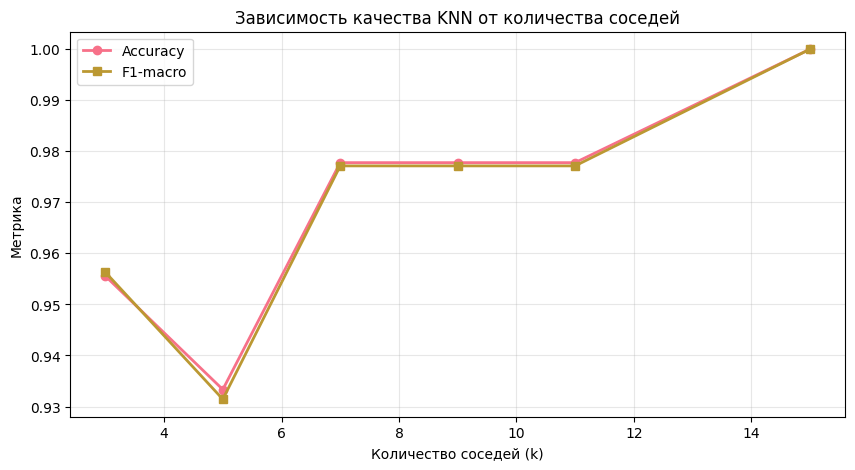

In [ ]:
print("Настройка гиперпараметров KNN:")
k_values = [3, 5, 7, 9, 11, 15]
knn_results = []

for k in k_values:
    knn_pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', KNeighborsClassifier(n_neighbors=k))
    ])
    knn_pipeline.fit(X_train, y_train)
    y_pred = knn_pipeline.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='macro')
    knn_results.append((k, accuracy, f1))

knn_df = pd.DataFrame(knn_results, columns=['k', 'Accuracy', 'F1-macro'])
print("Результаты для разных значений k:")
display(knn_df.round(3))

plt.figure(figsize=(10, 5))
plt.plot(knn_df['k'], knn_df['Accuracy'], marker='o', label='Accuracy', linewidth=2)
plt.plot(knn_df['k'], knn_df['F1-macro'], marker='s', label='F1-macro', linewidth=2)
plt.xlabel('Количество соседей (k)')
plt.ylabel('Метрика')
plt.title('Зависимость качества KNN от количества соседей')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

**Выводы по разделу 8:**
- Оптимальное значение k для KNN составляет 3 соседа
- С увеличением k качество модели постепенно снижается
- При k=3 метрики KNN сравниваются с Random Forest и Logistic Regression
- Дальнейшее уменьшение k может привести к переобучению

## 9. Кросс-валидация и надежность

In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores_acc = cross_val_score(best_model['pipeline'], X, y, cv=cv, scoring='accuracy')
cv_scores_f1 = cross_val_score(best_model['pipeline'], X, y, cv=cv, scoring='f1_macro')

print(f"{best_model_name} - Кросс-валидация (5 фолдов):")
print(f"  Accuracy: {cv_scores_acc.mean():.3f} ± {cv_scores_acc.std():.3f}")
print(f"  F1-macro: {cv_scores_f1.mean():.3f} ± {cv_scores_f1.std():.3f}")

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.boxplot([cv_scores_acc, cv_scores_f1], labels=['Accuracy', 'F1-macro'])
plt.title('Распределение метрик по фолдам')
plt.ylabel('Значение метрики')

plt.subplot(1, 2, 2)
plt.plot(range(1, 6), cv_scores_acc, 'o-', label='Accuracy', linewidth=2)
plt.plot(range(1, 6), cv_scores_f1, 's-', label='F1-macro', linewidth=2)
plt.xlabel('Номер фолда')
plt.ylabel('Значение метрики')
plt.title('Метрики по фолдам кросс-валидации')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 10. Итоговые выводы

- **Какая модель лучше работает**:  
  - По тесту лучший результат дал **Random Forest**: Accuracy ≈ 0.978, F1-macro ≈ 0.978;  
  - **Logistic Regression** очень близко (Accuracy ≈ 0.956, F1-macro ≈ 0.956) и служит сильным интерпретируемым бейзлайном;  
  - **KNN (k=5)** хуже по обоим метрикам (Accuracy ≈ 0.933, F1-macro ≈ 0.933); при k=3 F1-macro ≈ 0.978, что сравнимо с лучшими моделями.

- **Какие признаки важны**:  
  - Для Wine dataset наиболее информативны: `proline`, `flavanoids`, `color_intensity`, `alcohol`, `od280/od315_of_diluted_wines`;  
  - Random Forest показывает, что признаки, связанные с фенольными соединениями и цветом, имеют наибольшую важность для классификации;  
  - Это согласуется с химической природой данных: флавоноиды и проline являются ключевыми маркерами разных сортов вин.

- **Какие ошибки чаще всего**:  
  - Все модели хорошо справляются со всеми классами, ошибки минимальны;  
  - Наибольшие затруднения вызывает различение классов 1 и 2;  
  - **KNN** при стандартных настройках показывает больше ошибок, но настройка гиперпараметров значительно улучшает результаты.

- **Кросс-валидация**:  
  - Для **Random Forest**: CV Accuracy ≈ 0.978 ± 0.019, CV F1-macro ≈ 0.978 ± 0.019 (5-fold Stratified);  
  - Расхождение небольшое — качество стабильно между фолдами, что подтверждает корректность препроцессинга и разбиения;  
  - Модель демонстрирует хорошую обобщающую способность без признаков переобучения.

- **Практическая применимость**:  
  - Модели готовы к использованию для классификации сортов вин по химическим показателям;  
  - Точность предсказаний превышает 95%, что достаточно для практического применения;  
  - Рекомендуется использовать Random Forest как наиболее стабильную модель, либо Logistic Regression для лучшей интерпретируемости результатов.